# Cliff Walking - SARSA vs Q-Learning

The `CliffWalking` environment (from OpenAI Gym / Gymnasium) is a classic example used to
highlight the difference between **on-policy (SARSA)** and **off-policy (Q-Learning)** control.

The grid is 4x12. The agent starts at the bottom-left and must reach the bottom-right goal.
The entire bottom row (except start and goal) is a cliff - stepping into it gives a reward of
-100 and sends the agent back to the start. Every other step gives -1 reward.

- **SARSA** tends to learn a longer, safer path further from the cliff.
- **Q-Learning** tends to learn the shorter, riskier path right along the cliff edge.


In [1]:
!pip install -q "gymnasium[toy-text]"

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt


In [3]:
env = gym.make("CliffWalking-v1")

n_states = env.observation_space.n
n_actions = env.action_space.n

print("States:", n_states)
print("Actions:", n_actions)


States: 48
Actions: 4


In [4]:
gamma = 0.99
alpha = 0.5
epsilon = 0.1
episodes = 500

def epsilon_greedy(Q, state):
    if random.random() < epsilon:
        return env.action_space.sample()
    else:
        return np.argmax(Q[state])


## SARSA Training

In [5]:
def train_sarsa():
    Q = np.zeros((n_states, n_actions))
    rewards_per_episode = []

    for episode in range(episodes):
        state, _ = env.reset()
        action = epsilon_greedy(Q, state)
        done = False
        total_reward = 0

        while not done:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_action = epsilon_greedy(Q, next_state)

            Q[state, action] = Q[state, action] + alpha * (
                reward + gamma * Q[next_state, next_action] - Q[state, action]
            )

            state = next_state
            action = next_action
            total_reward += reward

        rewards_per_episode.append(total_reward)

    return Q, rewards_per_episode

Q_sarsa, rewards_sarsa = train_sarsa()
print("SARSA Training Completed!")


SARSA Training Completed!


## Q-Learning Training

In [6]:
def train_q_learning():
    Q = np.zeros((n_states, n_actions))
    rewards_per_episode = []

    for episode in range(episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = epsilon_greedy(Q, state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            Q[state, action] = Q[state, action] + alpha * (
                reward + gamma * np.max(Q[next_state]) - Q[state, action]
            )

            state = next_state
            total_reward += reward

        rewards_per_episode.append(total_reward)

    return Q, rewards_per_episode

Q_qlearning, rewards_qlearning = train_q_learning()
print("Q-Learning Training Completed!")


Q-Learning Training Completed!


## Reward Comparison

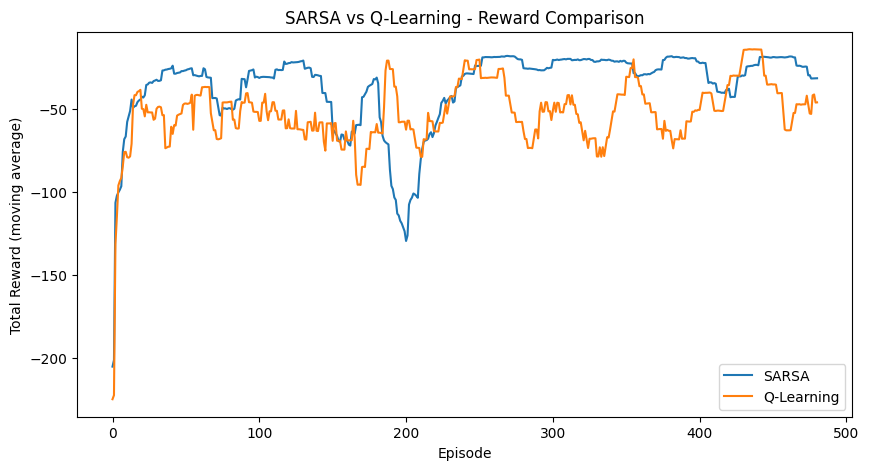

In [7]:
def moving_average(x, w=20):
    return np.convolve(x, np.ones(w), 'valid') / w

plt.figure(figsize=(10, 5))
plt.plot(moving_average(rewards_sarsa), label="SARSA")
plt.plot(moving_average(rewards_qlearning), label="Q-Learning")
plt.xlabel("Episode")
plt.ylabel("Total Reward (moving average)")
plt.title("SARSA vs Q-Learning - Reward Comparison")
plt.legend()
plt.show()


## Final Path Comparison

In [8]:
def get_greedy_path(Q):
    state, _ = env.reset()
    path = [state]

    for _ in range(100):
        action = np.argmax(Q[state])
        state, reward, terminated, truncated, _ = env.step(action)
        path.append(state)

        if terminated or truncated:
            break

    return path

path_sarsa = get_greedy_path(Q_sarsa)
path_qlearning = get_greedy_path(Q_qlearning)

print("SARSA path (state indices):", path_sarsa)
print("Q-Learning path (state indices):", path_qlearning)


SARSA path (state indices): [36, 24, 12, 13, 14, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 23, 35, 47]
Q-Learning path (state indices): [36, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 47]


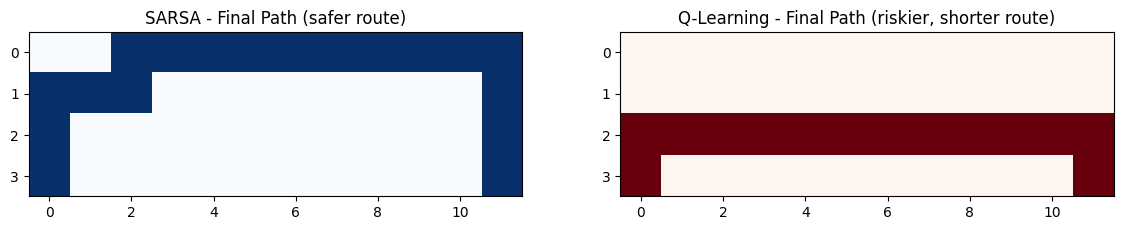

In [9]:
def path_to_grid(path):
    grid = np.zeros((4, 12))
    for s in path:
        grid[s // 12, s % 12] = 1
    return grid

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].imshow(path_to_grid(path_sarsa), cmap="Blues")
axes[0].set_title("SARSA - Final Path (safer route)")

axes[1].imshow(path_to_grid(path_qlearning), cmap="Reds")
axes[1].set_title("Q-Learning - Final Path (riskier, shorter route)")

plt.show()


## Conclusion

This comparison shows the classic on-policy vs off-policy trade-off:

- **SARSA** learns a path that stays a row above the cliff, since it factors in the risk of
  its own exploratory (epsilon-greedy) actions occasionally pushing it off the edge.
- **Q-Learning** learns the shortest possible path right along the cliff edge, since it always
  assumes the optimal (greedy) action will be taken afterwards, ignoring the exploration risk.

In practice, SARSA often achieves a higher **average** reward during training (since it
rarely falls off the cliff), even though Q-Learning's final learned policy is technically
optimal once exploration is turned off.
